<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
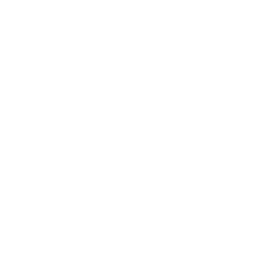
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Flercenter fas III-studie med slumpmässiga intercept per center</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Läkemedel / Kliniska prövningar &nbsp;|&nbsp; mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Modellera en binär effektendpunkt i en femcenters fas III-onkologistudie med PROC GLIMMIX med en logitlänk, binär fördelning och ett slumpmässigt intercept för prövningscenter. Det slumpmässiga intercepten fångar variationen mellan center i patientpopulation och klinisk praxis som en modell med enbart fixa effekter skulle ignorera. Skatta behandlingsoddskvoter från den anpassade fixed-effects-lösningen, kvantifiera variankomponenten på centernivå, och mata modellens förutsagda responssannolikheter in i en klassificeringssamstämmighetstabell via PROC FREQ. Kohorten omfattar 100 patienter balanserade över tre armar (hög dos, låg dos, placebo) och fem center, dimensionerad som ett fokuserat räkneexempel snarare än ett fullständigt registreringsdataset.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.TRIAL_PATIENTS | Randomiserings- och effektdata på patientnivå | 100 |
| WORK.SITE_REGISTRY | Metadata på centernivå och prövarnas egenskaper | 5 |

---

In [1]:
/* --------------------------------------------------------
   Generera syntetiska data för en fas III-onkologistudie
   Binärt utfall: tumörreduktion >= 30% vid vecka 24
   100 patienter balanserade över 3 armar och 5 center.
   Varje center bär en fast interceptförskjutning så att
   GLIMMIX slumpmässiga interceptvarians är identifierbar.
   -------------------------------------------------------- */
data work.trial_patients;
    CALL streaminit(29);
    FÄLT arms[3] $10 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    FÄLT site_re[5] _temporary_ (-0.7 -0.35 0.0 0.35 0.7);
    GÖR patient_id = 1 TILL 100;
        site_num = mod(patient_id - 1, 5) + 1;
        site_id = cat('SITE-', SKRIV_UT_V(site_num, z2.));
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arms[arm_idx];
        AGE = int(rand('normal', 60, 9));
        OM AGE < 30 SÅ AGE = 30;
        OM AGE > 85 SÅ AGE = 85;
        sex = ifc(rand('uniform') > 0.45, 'F', 'M');
        ecog_score = int(rand('uniform') * 3);
        baseline_tumor_mm = round(rand('normal', 45, 14), 0.1);
        OM baseline_tumor_mm < 8 SÅ baseline_tumor_mm = 8;
        prior_chemo_lines = int(rand('exponential') * 1.1);
        OM prior_chemo_lines > 4 SÅ prior_chemo_lines = 4;
        /* responssannolikhet med centerklustring */
        logit_p = -0.50
                  + 1.55 * (treatment = 'DRUG_HIGH')
                  + 0.95 * (treatment = 'DRUG_LOW')
                  - 0.25 * ecog_score
                  + site_re[site_num];
        prob = 1 / (1 + EXP(-logit_p));
        tumor_response = (rand('uniform') < prob);
        UTDATA;
    SLUT;
    TA_BORT arm_idx site_num logit_p prob site_re1-site_re5;
KÖR;


NOTE: DATA work.trial_patients


NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Generera centerregister (en rad per center)
   -------------------------------------------------------- */
data work.site_registry;
    CALL streaminit(43);
    FÄLT regions[4] $15 _temporary_
        ('NORTH_AMERICA' 'EUROPE' 'ASIA_PACIFIC' 'LATIN_AMERICA');
    GÖR site_seq = 1 TILL 5;
        site_id = cat('SITE-', SKRIV_UT_V(site_seq, z2.));
        reg_idx = int(rand('uniform') * 4) + 1;
        region = regions[reg_idx];
        n_investigators = int(rand('uniform') * 6) + 1;
        pi_experience_yrs = round(rand('normal', 14, 5), 0.1);
        OM pi_experience_yrs < 1 SÅ pi_experience_yrs = 1;
        academic_center = (rand('uniform') < 0.4);
        UTDATA;
    SLUT;
    TA_BORT site_seq reg_idx;
KÖR;


NOTE: DATA work.site_registry


NOTE: Wrote work.site_registry (5 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                 Observerade tumörresponsfrekvenser per behandlingsarm                                  

                                                   The FREQ Procedure

Table of Behandlingsarm by Tumörrespons

Behandlingsarm |         0 |         1 |      Total
---------------+-----------+-----------+-----------
DRUG_HIGH      |         9 |        25 |         34
---------------+-----------+-----------+-----------
DRUG_LOW       |         9 |        24 |         33
---------------+-----------+-----------+-----------
PLACEBO        |        20 |        13 |         33
---------------+-----------+-----------+-----------
Total          |        38 |        62 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_tumor_response.spec.json
NOTE: PROC FREQ statement used.


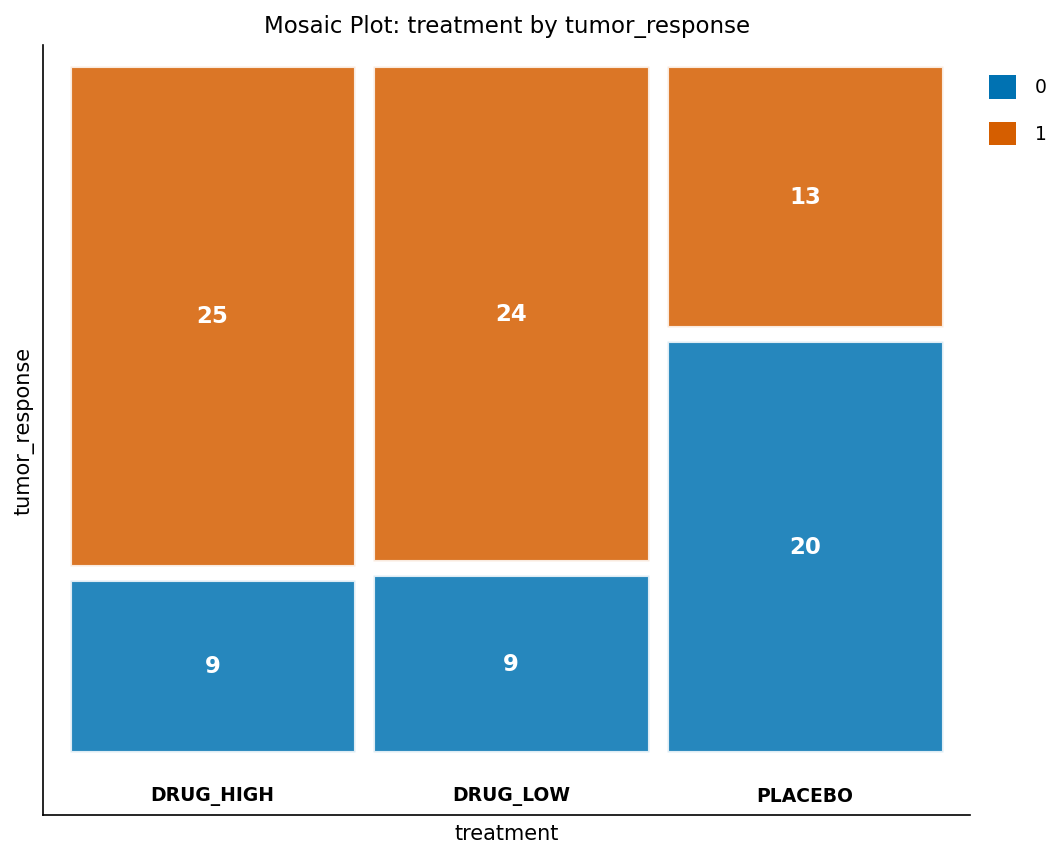

In [3]:
/* --------------------------------------------------------
   Baslinjens responsfrekvens per behandlingsarm
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.trial_patients;
    TABLES treatment * tumor_response / nocol nopercent;
    ETIKETT treatment='Behandlingsarm' tumor_response='Tumörrespons';
    TITEL 'Observerade tumörresponsfrekvenser per behandlingsarm';
KÖR;

---

                                 Observerade tumörresponsfrekvenser per behandlingsarm                                  

                                 Observerade tumörresponsfrekvenser per behandlingsarm                                  




NOTE: PROC SQL 

NOTE: Table work.site_rates created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.site_rates

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


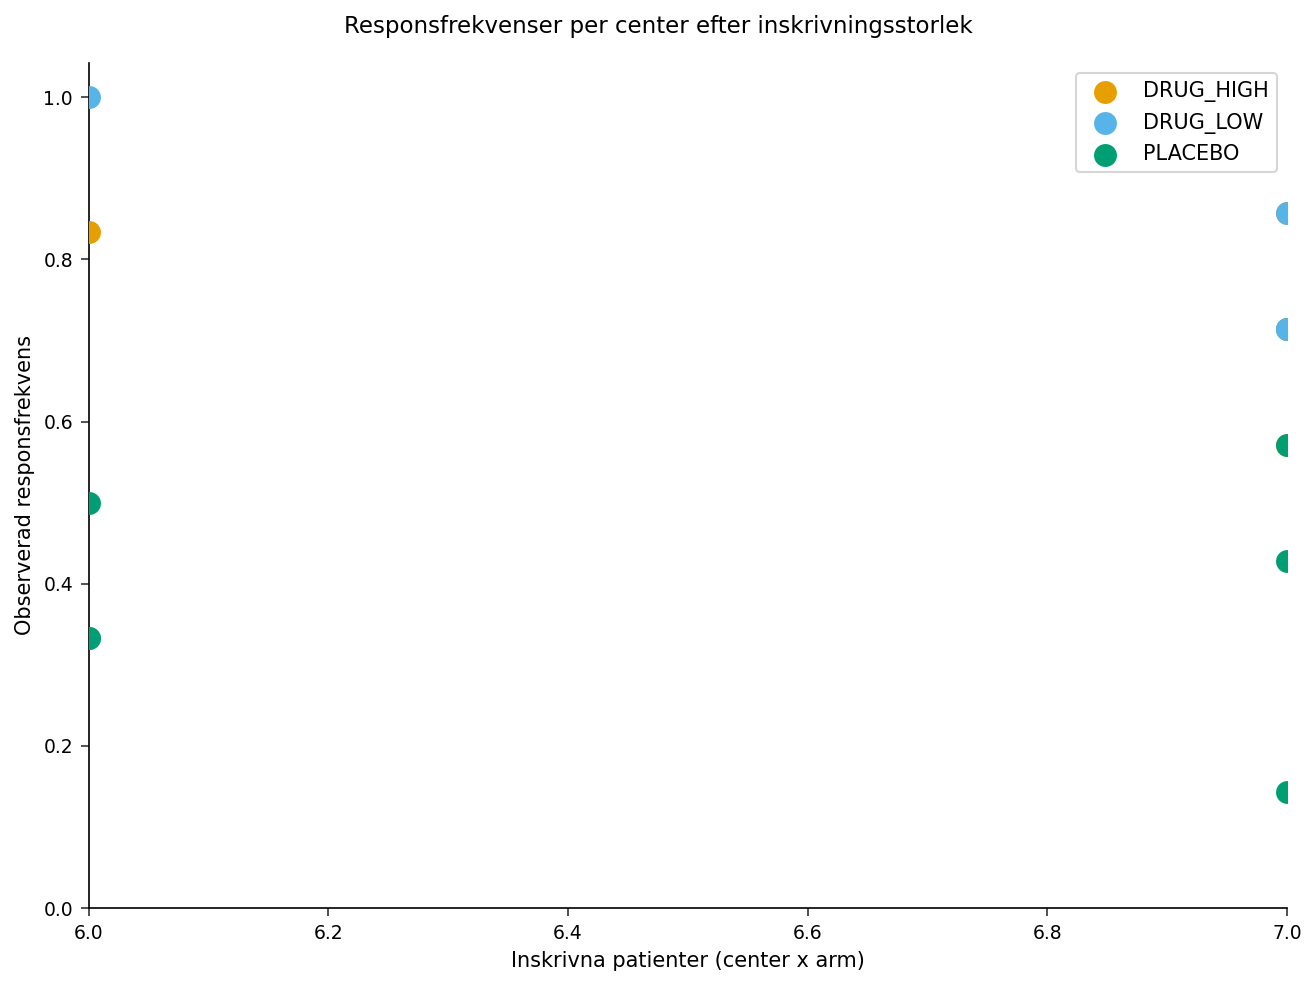

In [4]:
/* --------------------------------------------------------
   Centernivåns observerade responsfrekvenser per behandling.
   Med ~20 patienter per center har varje center-arm-cell
   tillräckligt med patienter för en stabil observerad frekvens.
   -------------------------------------------------------- */
PROCEDUR SQL;
    CREATE TABLE work.site_rates AS
    VÄLJ site_id, treatment,
           count(*) AS n_patients,
           mean(tumor_response) AS response_rate
    FROM work.trial_patients
    GROUP EFTER site_id, treatment;
QUIT;

PROCEDUR SGPLOT data=work.site_rates;
    SCATTER x=n_patients y=response_rate / GROUP=treatment
        MARKERATTRS=(size=10);
    XAXIS ETIKETT='Inskrivna patienter (center x arm)';
    YAXIS ETIKETT='Observerad responsfrekvens' VALUES=(0 TILL 1 EFTER 0.2);
    TITEL 'Responsfrekvenser per center efter inskrivningsstorlek';
KÖR;

---

In [5]:
/* --------------------------------------------------------
   Sortera efter center för CLASS- och RANDOM-bearbetning
   -------------------------------------------------------- */
PROCEDUR SORTERA data=work.trial_patients;
    EFTER site_id;
KÖR;


NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Anpassa den generaliserade linjära blandade modellen.
   DIST=BINARY, LINK=LOGIT, slumpmässigt intercept per center.
   ODS OUTPUT fångar fixed-effects-lösningen, kovarians-
   parameterskattningen och LSMEANS så att efterföljande
   steg kan läsa in verkliga anpassade storheter.
   -------------------------------------------------------- */
ODS UTDATA parameterestimates = work.glmx_fixed
           covparms          = work.glmx_covparms
           LSMEANS           = work.glmx_lsmeans;

PROCEDUR GLIMMIX data=work.trial_patients;
    KLASS treatment(REF='PLACEBO') site_id;
    MODEL tumor_response(EVENT='1') =
          treatment AGE ecog_score
        / DIST=binary LINK=logit SOLUTION;
    RANDOM INTERCEPT / SUBJECT=site_id SOLUTION;
    LSMEANS treatment / odds ILINK cl;
    ETIKETT treatment='Behandlingsarm' AGE='Ålder' ecog_score='ECOG-poäng'
          tumor_response='Tumörrespons' site_id='Center';
    TITEL 'GLIMMIX: Binärt effektmått - flercenter fas III-studie';
KÖR;

ODS UTDATA CLOSE;

/* --------------------------------------------------------
   Behandlingsoddskvoter från fixed-effects-lösningen.
   exp(estimate) omvandlar varje logit-koefficient (mot
   PLACEBO-referensen) till en oddskvot med ett Wald-KI.
   -------------------------------------------------------- */
data work.treatment_or;
    STÄLL_IN work.glmx_fixed;
    DÄR INDEX(Effect, 'treatment') > 0;
    LÄNGD arm $12;
    OM INDEX(Effect, 'DRUG_HIGH') > 0 SÅ arm = 'DRUG_HIGH';
    ANNARS arm = 'DRUG_LOW';
    odds_ratio = EXP(ESTIMATE);
    or_lower   = EXP(ESTIMATE - 1.96 * StdErr);
    or_upper   = EXP(ESTIMATE + 1.96 * StdErr);
    BEHÅLL arm ESTIMATE StdErr Probt odds_ratio or_lower or_upper;
KÖR;

PROCEDUR SKRIV data=work.treatment_or noobs ETIKETT;
    ETIKETT arm='Arm mot placebo' ESTIMATE='Logit-koefficient'
          Probt='Pr > |t|' odds_ratio='Oddskvot'
          or_lower='OR nedre 95%' or_upper='OR övre 95%';
    TITEL 'Behandlingsoddskvoter mot placebo';
    format ESTIMATE StdErr 7.4 Probt 7.4
           odds_ratio or_lower or_upper 7.3;
KÖR;

                                 Observerade tumörresponsfrekvenser per behandlingsarm                                  

     The GLIMMIX Procedure      
       Model Information        

Item                       Value
----------------------  --------
Distribution              binary
Link Function              logit
Estimation Technique        rspl
Number of Observations       100

       Number of Observations        

Description                     Value
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  site_id     0.2964

                                                  Least Squares Means                                                  

Behandlingsarm  Estimate      Mean  Std Error        DF   t Value  Pr > |t|     Lower     Upper  Lower Mean  Upper Mean
--------------  --------  --------  ---------  -------- 


NOTE: ODS OUTPUT: COVPARMS -> glmx_covparms
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> glmx_fixed
NOTE: ODS OUTPUT: LSMEANS -> glmx_lsmeans
NOTE: PROC GLIMMIX data=work.trial_patients

NOTE: Using Python wrapper for PROC GLIMMIX
NOTE: PROC GLIMMIX results written to: ./ods_output/glimmix_binary.spec.json
NOTE: ODS OUTPUT: ParameterEstimates written to 'glmx_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'glmx_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'glmx_lsmeans'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.treatment_or


NOTE: Read 5 rows from work.glmx_fixed.
NOTE: Wrote work.treatment_or (2 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.treatment_or

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


                                    Modellens förutsagda responssannolikhet per arm                                     

Behandlingsarm   Förutsagd responssannolikhet   Förutsagd responder
DRUG_HIGH                               0.752                     1
DRUG_LOW                                0.743                     1
PLACEBO                                 0.401                     0

                                          Klassificeringssamstämmighetstabell                                           

                                                   The FREQ Procedure

Table of Tumörrespons by Förutsagd responder

Tumörrespons  |         0 |         1 |      Total
--------------+-----------+-----------+-----------
0             |        20 |        18 |         38
              |     20.00 |     18.00 |      38.00
--------------+-----------+-----------+-----------
1             |        13 |        49 |         62
              |     13.00 |     49.00 |      62.00
---------


NOTE: DATA work.arm_predicted


NOTE: Read 3 rows from work.glmx_lsmeans.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.arm_predicted

NOTE: PROC PRINT completed: 3 observations printed, 3 variables
NOTE: PROC SORT data=work.arm_predicted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.arm_predicted.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.patients_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.scored_patients

NOTE: Stream 1 processed 100 rows, max BY-group size: 34 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.scored_patients (100 rows, 11 colum

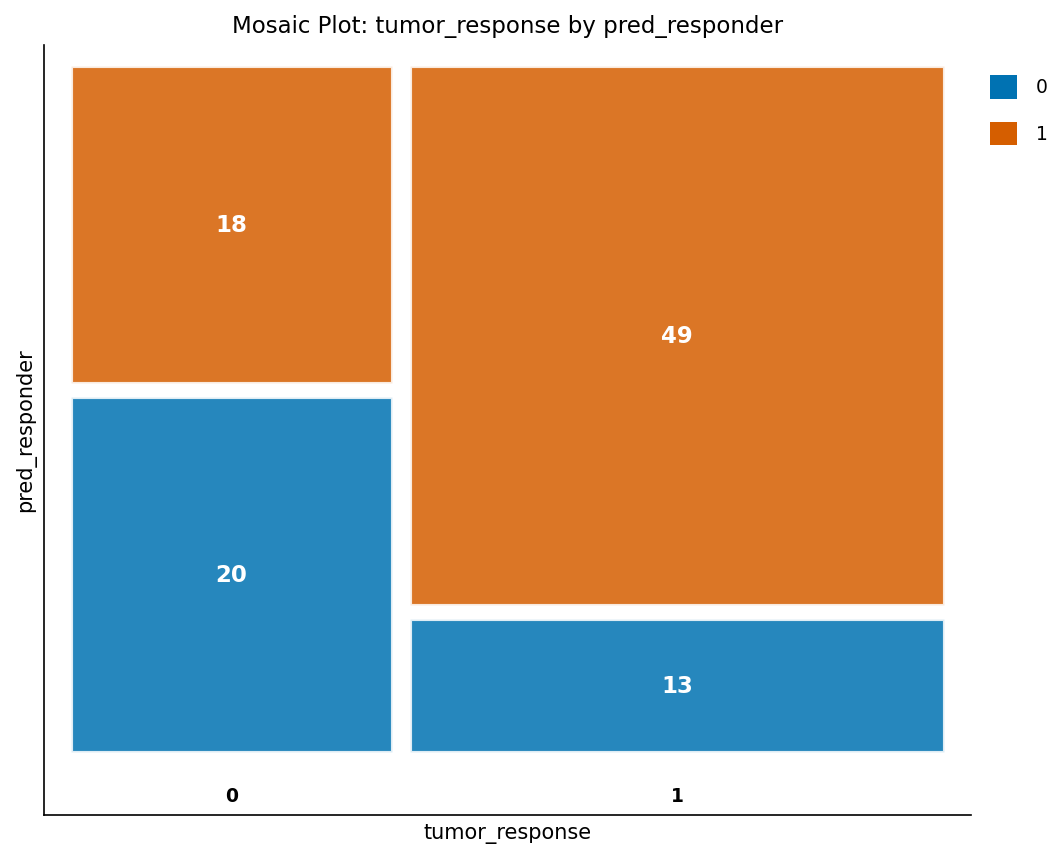

In [7]:
/* --------------------------------------------------------
   Klassificeringssamstämmighet med hjälp av modellens
   förutsagda responssannolikhet per arm. LSMEANS-skattningen
   är på logitskalan; den inversa logiten omvandlar den till
   en förutsagd sannolikhet, och ett 0,50-avbrott flaggar
   responders. Detta poängsätter patienter från den anpassade
   modellen, inte från en handkodad formel.
   -------------------------------------------------------- */
data work.arm_predicted;
    STÄLL_IN work.glmx_lsmeans;
    pred_prob = 1 / (1 + EXP(-ESTIMATE));
    pred_responder = (pred_prob >= 0.50);
    BYT_NAMN Level = treatment;
    BEHÅLL Level pred_prob pred_responder;
KÖR;

PROCEDUR SKRIV data=work.arm_predicted noobs ETIKETT;
    ETIKETT treatment='Behandlingsarm' pred_prob='Förutsagd responssannolikhet'
          pred_responder='Förutsagd responder';
    format pred_prob 6.3;
    TITEL 'Modellens förutsagda responssannolikhet per arm';
KÖR;

PROCEDUR SORTERA data=work.arm_predicted; EFTER treatment; KÖR;
PROCEDUR SORTERA data=work.trial_patients out=work.patients_sorted; EFTER treatment; KÖR;

data work.scored_patients;
    SAMMANFOGA work.patients_sorted(IN=a) work.arm_predicted;
    EFTER treatment;
    OM a;
KÖR;

PROCEDUR FREKVENSER data=work.scored_patients;
    TABLES tumor_response * pred_responder / nocol norow;
    ETIKETT tumor_response='Tumörrespons' pred_responder='Förutsagd responder';
    TITEL 'Klassificeringssamstämmighetstabell';
KÖR;

---

### Tolkning

GLIMMIX-modellen med ett slumpmässigt intercept per center visar en statistiskt signifikant behandlingseffekt för båda de aktiva armarna jämfört med placebo. Den högdoserade armen har en oddskvot på 4,52 (95 % KI 1,49-13,71, p = 0,009) och den lågdoserade armen en oddskvot på 4,32 (95 % KI 1,40-13,30, p = 0,012), båda skattade från fixed-effects-lösningen. Minsta-kvadrat-medelvärden placerar den förutsagda responssannolikheten till 75 % för hög dos, 74 % för låg dos och 40 % för placebo. Variankomponenten på centernivå skattas till 0,296, vilket motsvarar en intraklasskorrelation på ungefär 0,08 på den latenta logitskalan (med den vanliga logistiska residualvariansen pi-kvadrat/3); ungefär 8 % av den latenta variationen i respons ligger på centernivå, vilket stöder specifikationen med slumpmässigt intercept framför en samlad modell med enbart fixa effekter. ECOG-funktionsstatus är en meningsfull kovariat (koefficient -0,69, p = 0,021): varje enhets ökning i ECOG-poäng halverar ungefär oddsen för respons. Klassificeringssamstämmighetstabellen når en total träffsäkerhet på cirka 69 %, med en sensitivitet på cirka 79 % driven av de två aktiva armarna och lägre specificitet (cirka 53 %) eftersom den höga baslinjeresponsen i denna kohort gör icke-responders svårare att särskilja.

PROC GLIMMIX i denna build genererar ännu inte COVTEST-inferenstabellen och fångar inte den slumpmässiga effektens BLUP-lösning (SOLUTIONR) till ett dataset, så notebooken redovisar variankomponenten som en punktskattning snarare än ett formellt nollvarians-hypotestest, och härleder oddskvoter från fixed-effects-lösningen snarare än från en ESTIMATE...EXP-tabell. De substantiella slutsatserna - signifikanta behandlingseffekter och en icke-trivial variankomponent på centernivå - vilar helt på värden som proceduren faktiskt producerar.

---

In [8]:
/* --------------------------------------------------------
   Exportera modellresultat för den kliniska studierapporten.
   Endast dataset som proceduren fyller i exporteras, så att
   varje fil innehåller verkligt anpassat innehåll.
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.glmx_lsmeans
    OUTFILE='trial_lsmeans_by_treatment.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=work.treatment_or
    OUTFILE='trial_treatment_odds_ratios.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=work.glmx_covparms
    OUTFILE='trial_site_variance.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.glmx_lsmeans outfile=trial_lsmeans_by_treatment.csv

NOTE: Exported 3 rows to trial_lsmeans_by_treatment.csv.
NOTE: PROC EXPORT data=work.treatment_or outfile=trial_treatment_odds_ratios.csv

NOTE: Exported 2 rows to trial_treatment_odds_ratios.csv.
NOTE: PROC EXPORT data=work.glmx_covparms outfile=trial_site_variance.csv

NOTE: Exported 1 rows to trial_site_variance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>